In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,primary_pollutant,hour,day,weekday
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,14,17,Friday
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,14,17,Friday
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,15,17,Friday
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,159.0,pm2_5,16,17,Friday
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,164.0,pm2_5,18,17,Friday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 371 non-null    int64  
 1   timestamp          371 non-null    object 
 2   aqi                371 non-null    int64  
 3   pm2_5              371 non-null    float64
 4   pm10               371 non-null    float64
 5   co                 371 non-null    float64
 6   no2                371 non-null    float64
 7   o3                 371 non-null    float64
 8   so2                371 non-null    float64
 9   calculated_aqi     371 non-null    float64
 10  primary_pollutant  371 non-null    object 
 11  hour               371 non-null    int64  
 12  day                371 non-null    int64  
 13  weekday            371 non-null    object 
dtypes: float64(7), int64(4), object(3)
memory usage: 40.7+ KB


In [4]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,hour,day
count,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000,371.000000
mean,186.000000,3.091644,40.202183,45.938356,589.312668,14.196173,54.003612,6.560593,107.789757,17.199461,16.070081
std,107.242715,0.907751,19.607953,22.776652,245.020582,8.312154,32.663811,1.984247,37.386209,4.449488,8.609890
min,1.000000,1.000000,7.140000,8.460000,248.980000,1.890000,0.220000,2.820000,30.000000,0.000000,1.000000
25%,93.500000,3.000000,27.075000,30.145000,386.060000,7.435000,29.940000,5.220000,82.500000,14.000000,9.000000
50%,186.000000,3.000000,36.930000,40.430000,547.200000,12.800000,52.060000,6.300000,105.000000,18.000000,18.000000
75%,278.500000,4.000000,52.540000,61.395000,729.595000,18.985000,74.600000,7.550000,143.000000,21.000000,22.000000
max,371.000000,5.000000,97.470000,119.310000,1310.840000,39.280000,146.150000,16.110000,173.000000,23.000000,31.000000


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 371
Columns: 14


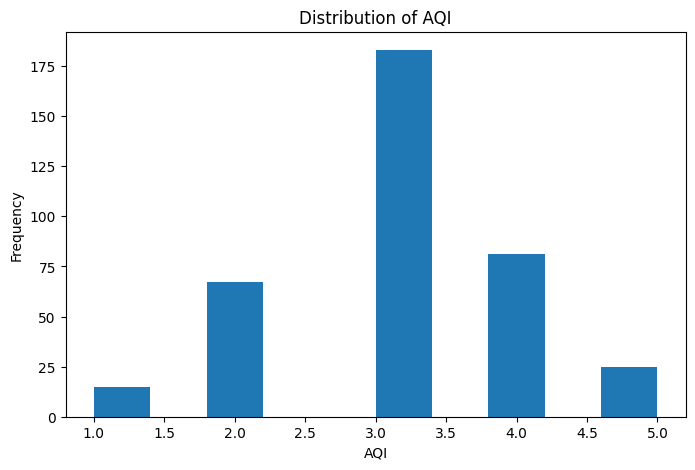

In [6]:
#aqi distribution
plt.figure(figsize=(8,5))

plt.hist(df["aqi"], bins=10)

plt.title("Distribution of AQI")

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.show()

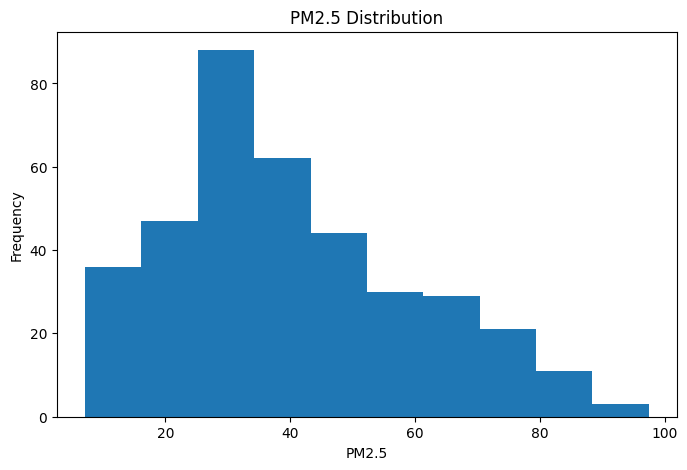

In [7]:
#PM 2.5 distribution
plt.figure(figsize=(8,5))

plt.hist(df["pm2_5"], bins=10)

plt.title("PM2.5 Distribution")

plt.xlabel("PM2.5")

plt.ylabel("Frequency")

plt.show()

In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

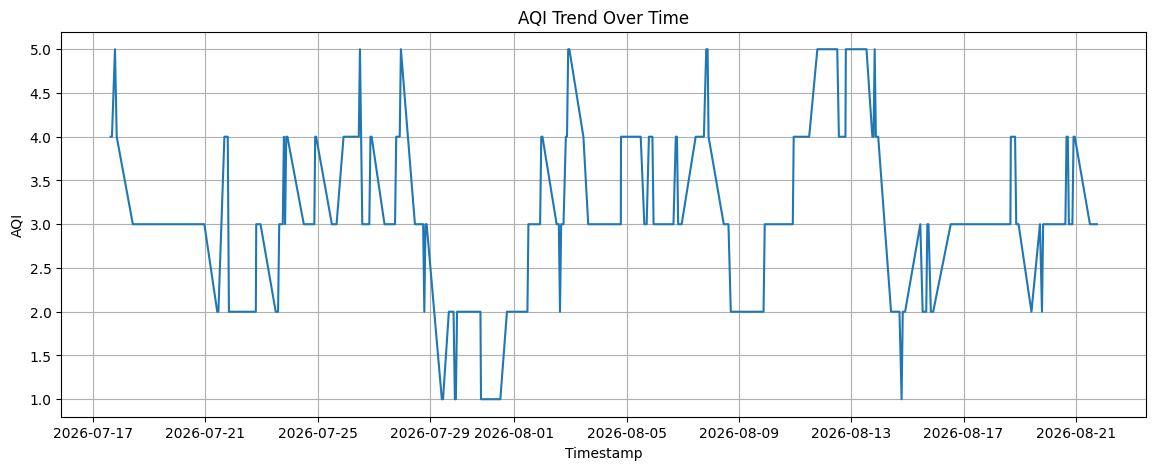

In [9]:
#AQI trend over time
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["aqi"])

plt.title("AQI Trend Over Time")

plt.xlabel("Timestamp")

plt.ylabel("AQI")

plt.grid(True)

plt.show()

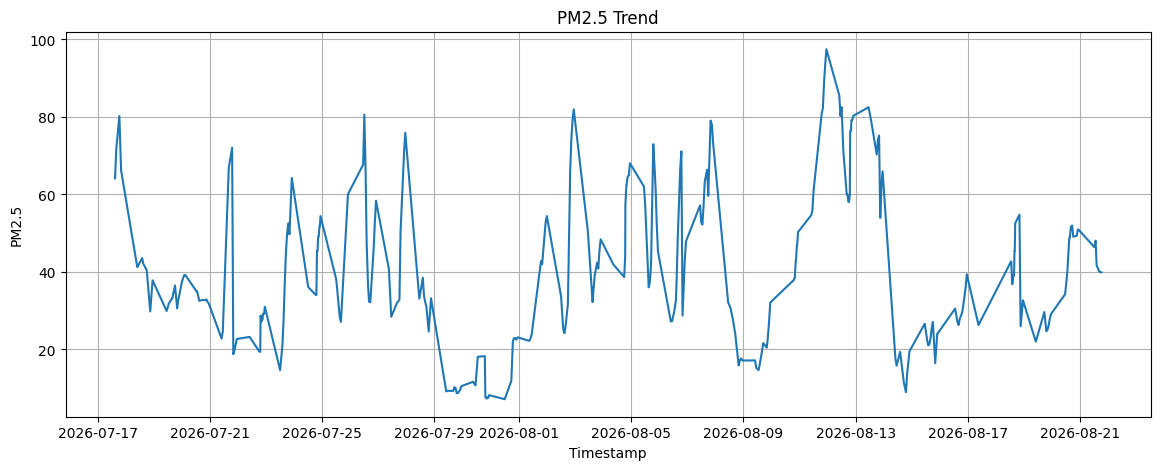

In [10]:
plt.figure(figsize=(14,5))

plt.plot(df["timestamp"], df["pm2_5"])

plt.title("PM2.5 Trend")

plt.xlabel("Timestamp")

plt.ylabel("PM2.5")

plt.grid(True)

plt.show()

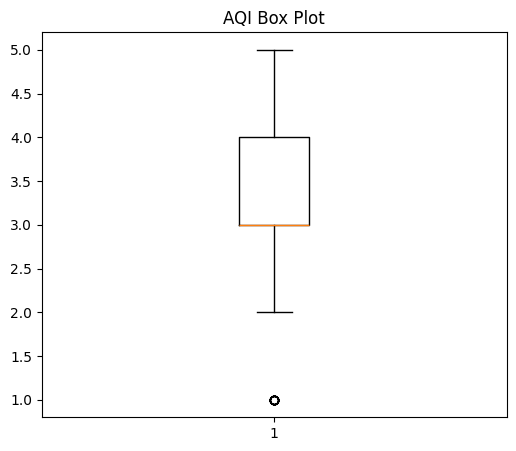

In [11]:
plt.figure(figsize=(6,5))

plt.boxplot(df["aqi"])

plt.title("AQI Box Plot")

plt.show()

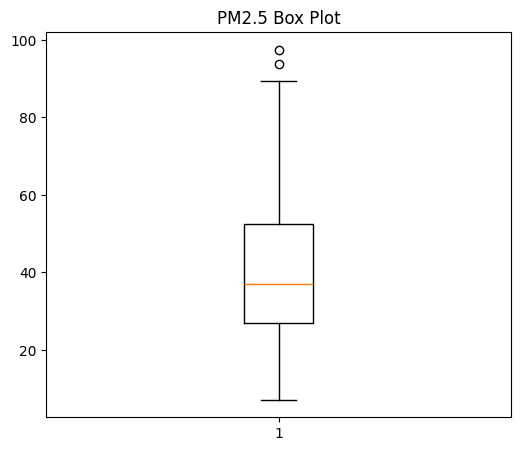

In [12]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm2_5"])

plt.title("PM2.5 Box Plot")

plt.show()

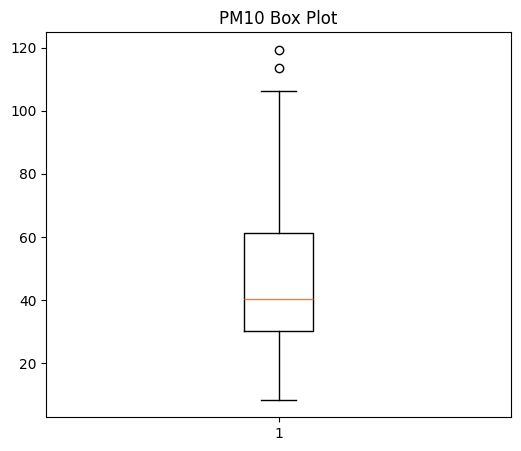

In [13]:
plt.figure(figsize=(6,5))

plt.boxplot(df["pm10"])

plt.title("PM10 Box Plot")

plt.show()

In [14]:
correlation = df.corr(numeric_only=True)

correlation

,id,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,hour,day
id,1.000000,0.119047,0.121084,0.147634,-0.136863,-0.178523,0.191090,0.140812,0.119643,0.071491,-0.348017
aqi,0.119047,1.000000,0.934814,0.916725,0.555413,0.324724,0.121210,0.574271,0.923414,0.069068,-0.352510
pm2_5,0.121084,0.934814,1.000000,0.986684,0.599164,0.359806,0.124211,0.633707,0.974344,0.101572,-0.357386
pm10,0.147634,0.916725,0.986684,1.000000,0.660709,0.438977,0.028839,0.692614,0.958927,0.184831,-0.364732
co,-0.136863,0.555413,0.599164,0.660709,1.000000,0.901622,-0.663301,0.723732,0.618488,0.192232,-0.388222
no2,-0.178523,0.324724,0.359806,0.438977,0.901622,1.000000,-0.804457,0.731470,0.371082,0.286761,-0.246257
o3,0.191090,0.121210,0.124211,0.028839,-0.663301,-0.804457,1.000000,-0.352992,0.106507,-0.175465,0.173454
so2,0.140812,0.574271,0.633707,0.692614,0.723732,0.731470,-0.352992,1.000000,0.616400,0.282744,-0.283928
calculated_aqi,0.119643,0.923414,0.974344,0.958927,0.618488,0.371082,0.106507,0.616400,1.000000,0.078921,-0.384128
hour,0.071491,0.069068,0.101572,0.184831,0.192232,0.286761,-0.175465,0.282744,0.078921,1.000000,0.020164


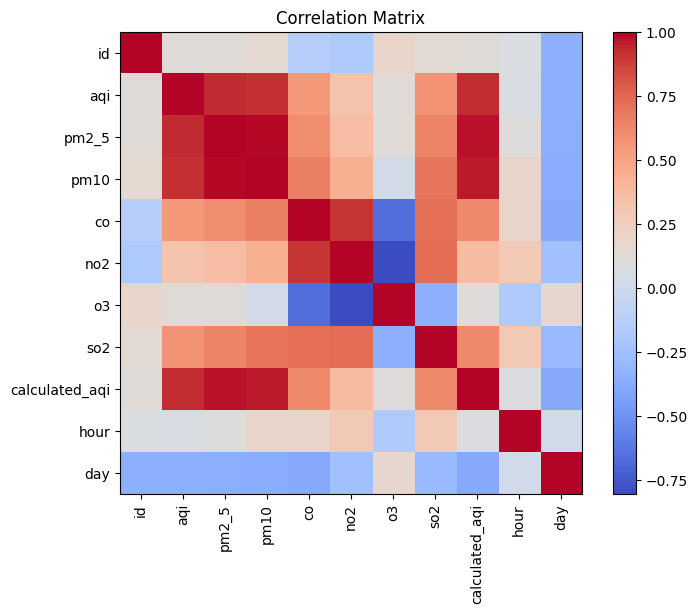

In [15]:
#correlation heatmap
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

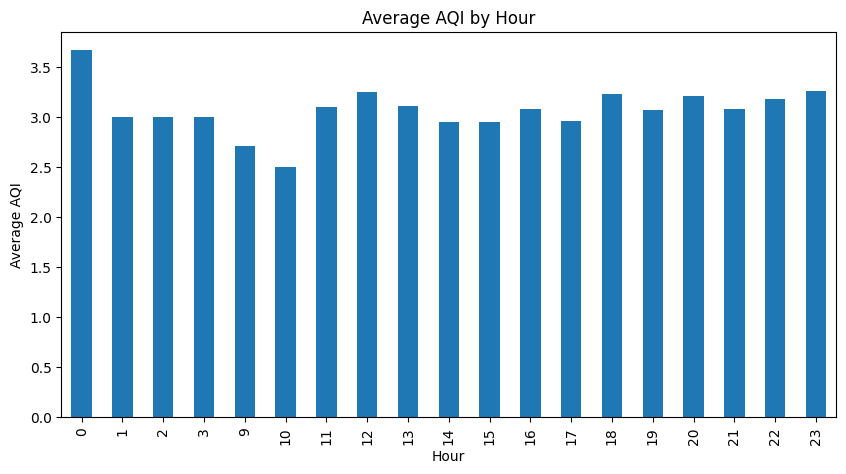

In [16]:
#avg aqi by hour
hourly = df.groupby("hour")["aqi"].mean()

hourly.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Hour")

plt.xlabel("Hour")

plt.ylabel("Average AQI")

plt.show()

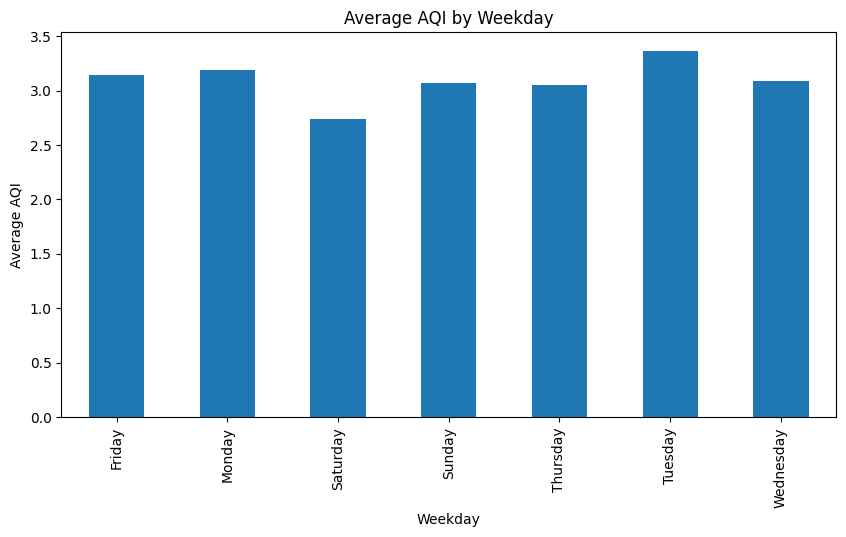

In [17]:
weekday = df.groupby("weekday")["aqi"].mean()

weekday.plot(kind="bar", figsize=(10,5))

plt.title("Average AQI by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Average AQI")

plt.show()

In [18]:
summary = df.describe()

summary.to_csv("../data/eda_summary.csv")

In [19]:
conn.close()